# Phase 4 — Uplift Evaluation and Targeting Strategy

## TL;DR

- **Visit**: recommended uplift model is `s_learner`; deployment ranking is `s_learner` at Top 30%, with 24,765.2 estimated incremental outcomes.
- **Conversion**: recommended uplift model is `s_learner`; deployment ranking is `response_propensity` at Top 30%, with 3,023.4 estimated incremental outcomes.

The test set was opened only after the model candidates, targeting rates, metrics, confidence
level, and bootstrap rules were frozen. Model choice still considers Top 10/20/30 gains and nearby
targeting rates rather than a single Qini point estimate.

## 1. Evaluation boundary

- Phase 3 models are frozen; they are not retrained or tuned here.
- Test outcomes are first opened in the `evaluate` stage.
- Users are ranked by continuous score; negative uplift scores are retained.
- Cumulative gain is evaluated every 5% from Top 5% through Top 100%.
- Visit group diagnostics use 20 groups; conversion uses 10 because conversion is rarer.
- Top 10%, 20%, and 30% are the main policy decision points.
- Calibration is a linear rescaling for interpretation and does not change ranking.
- Constant-ATE, segment-uplift, response-propensity, random, target-none, and target-all references
  are included.
- Phase 3 stability is recomputed with the current S/T/X implementation at an alternate seed.
- Visit-versus-conversion ranking correlation, policy overlap, and cross-policy gains are included.
- The added completion analyses are labeled exploratory because they were requested after the
  initial test review; Phase 3 models were not retuned.

## 2. Setup and saved artifacts

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("Could not locate the AdLift project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CONFIG_PATH = PROJECT_ROOT / "config" / "phase4_evaluation.json"
TABLE_DIRECTORY = PROJECT_ROOT / "reports" / "tables" / "phase4"
FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures" / "phase4"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "processed" / "phase4"
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation spec frozen: {(OUTPUT_ROOT / 'EVALUATION_SPEC.json').exists()}")
print(f"Test evaluation complete: {(OUTPUT_ROOT / 'TEST_EVALUATED.json').exists()}")

Project root: /Users/ever/Library/CloudStorage/OneDrive2-ColumbiaUniversityIrvingMedicalCenter/adlift项目
Evaluation spec frozen: True
Test evaluation complete: True


## 3. Handoff and test-set protection

In [2]:
lock_path = OUTPUT_ROOT / "EVALUATION_SPEC.json"
if lock_path.exists():
    lock = json.loads(lock_path.read_text(encoding="utf-8"))
    display(pd.DataFrame([
        {
            "outcome": outcome,
            "test_rows": details["rows"],
            "phase3_run_hash": details["phase3_run_hash"],
            "test_outcomes_used_during_prepare": lock["test_outcomes_used"],
            "response_baseline_rows": lock["response_baselines"][outcome]["rows"],
        }
        for outcome, details in lock["handoff"].items()
    ]))
else:
    display(Markdown("Run the Phase 4 `prepare` command before evaluation."))

,outcome,test_rows,phase3_run_hash,test_outcomes_used_during_prepare,response_baseline_rows
0,visit,2795749,387b8aa30d048f5124cfcfc1818c52be8b8096923715c1...,False,2795749
1,conversion,2795749,fc0b7e623f3411e84d635edfd313db2f02c3ba601f3f78...,False,2795749


## 4. Baseline definitions and validation-only segment selection

In [3]:
baseline_rows = []
segment_selection = []
for outcome in config["outcomes"]:
    metadata_path = OUTPUT_ROOT / "baselines" / outcome / "structural_metadata.json"
    selection_path = TABLE_DIRECTORY / f"{outcome}_segment_baseline_selection.csv"
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        baseline_rows.append({
            "outcome": outcome,
            "constant_ate_train_validation": metadata["constant_ate_train_validation"],
            "selected_segment_feature": metadata["selected_feature"],
            "segment_bins": metadata["actual_bins"],
            "validation_qini": metadata["validation_qini"],
            "test_outcomes_used": metadata["test_outcomes_used"],
        })
    if selection_path.exists():
        candidates = pd.read_csv(selection_path)
        segment_selection.append(candidates.head(8))
if baseline_rows:
    display(pd.DataFrame(baseline_rows).round(6))
if segment_selection:
    display(pd.concat(segment_selection, ignore_index=True).round(4))

,outcome,constant_ate_train_validation,selected_segment_feature,segment_bins,validation_qini,test_outcomes_used
0,visit,0.010344,f6,7,9354.050080,False
1,conversion,0.001145,f8,5,1215.974033,False


,outcome_name,feature,requested_bins,actual_bins,train_ate,validation_auuc,validation_qini
0,visit,f6,8,7,0.0104,23698.3153,9354.0501
1,visit,f8,8,5,0.0104,23632.7424,9288.4772
2,visit,f3,8,3,0.0104,23601.8713,9257.6061
3,visit,f8,5,4,0.0104,23388.3192,9044.0539
4,visit,f3,2,2,0.0104,23187.2534,8842.9881
5,visit,f3,3,2,0.0104,23187.2534,8842.9881
6,visit,f3,5,2,0.0104,23187.2534,8842.9881
7,visit,f6,5,5,0.0104,23179.6375,8835.3722
8,conversion,f8,8,5,0.0011,2838.7029,1215.9740
9,conversion,f8,5,4,0.0011,2772.1064,1149.3775


## 5. Top 100% ATE sanity check

In [4]:
ate_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_ate_sanity.csv"
    if path.exists():
        ate_tables.append(pd.read_csv(path))
if ate_tables:
    ate_sanity = pd.concat(ate_tables, ignore_index=True)
    display(ate_sanity.round(8))
    assert (
        (ate_sanity["endpoint_gain"] - ate_sanity["expected_endpoint_gain"]).abs()
        < 1e-6
    ).all()
else:
    display(Markdown("ATE sanity results will appear after the formal evaluation."))

,outcome_name,test_rows,test_ate,phase2_ate,test_minus_phase2_ate,endpoint_gain,expected_endpoint_gain
0,visit,2795749,0.010335,0.010342,-0.000008,28893.317518,28893.317518
1,conversion,2795749,0.001179,0.001152,0.000027,3296.443876,3296.443876


## 6. Observed uplift by score group

,outcome_name,model_name,score_group,population_start_pct,population_end_pct,group_rows,treatment_rows,control_rows,treatment_rate,control_rate,observed_uplift,mean_predicted_score,incremental_outcomes,uplift_ci_lower,uplift_ci_upper
0,visit,s_learner,1,0.0,10.0,279575,242346,37229,0.291228,0.227135,0.064093,0.058614,17918.935616,0.059469,0.068718
1,visit,s_learner,2,10.0,20.0,279575,237258,42317,0.120847,0.114517,0.006331,0.008678,1769.911908,0.003025,0.009636
2,visit,s_learner,3,20.0,30.0,279575,236910,42665,0.039154,0.037501,0.001653,0.002765,462.038017,-0.000312,0.003617
3,visit,s_learner,4,30.0,40.0,279575,237098,42477,0.012349,0.011748,0.000602,0.001068,168.245425,-0.000515,0.001719
4,visit,s_learner,5,40.0,50.0,279575,236685,42890,0.005729,0.004920,0.000810,0.000607,226.336089,0.000081,0.001538
5,visit,s_learner,6,50.0,60.0,279575,236965,42610,0.003195,0.002112,0.001082,0.000393,302.607607,0.000591,0.001574
6,visit,s_learner,7,60.0,70.0,279575,237131,42444,0.001834,0.001390,0.000444,0.000242,124.232551,0.000050,0.000838
7,visit,s_learner,8,70.0,80.0,279575,237429,42146,0.001036,0.000736,0.000301,0.000133,84.029299,0.000011,0.000590
8,visit,s_learner,9,80.0,90.0,279575,237431,42144,0.000611,0.000522,0.000089,0.000085,24.793829,-0.000151,0.000328
9,visit,s_learner,10,90.0,100.0,279574,237278,42296,0.004986,0.005698,-0.000712,0.000001,-199.119698,-0.001484,0.000059


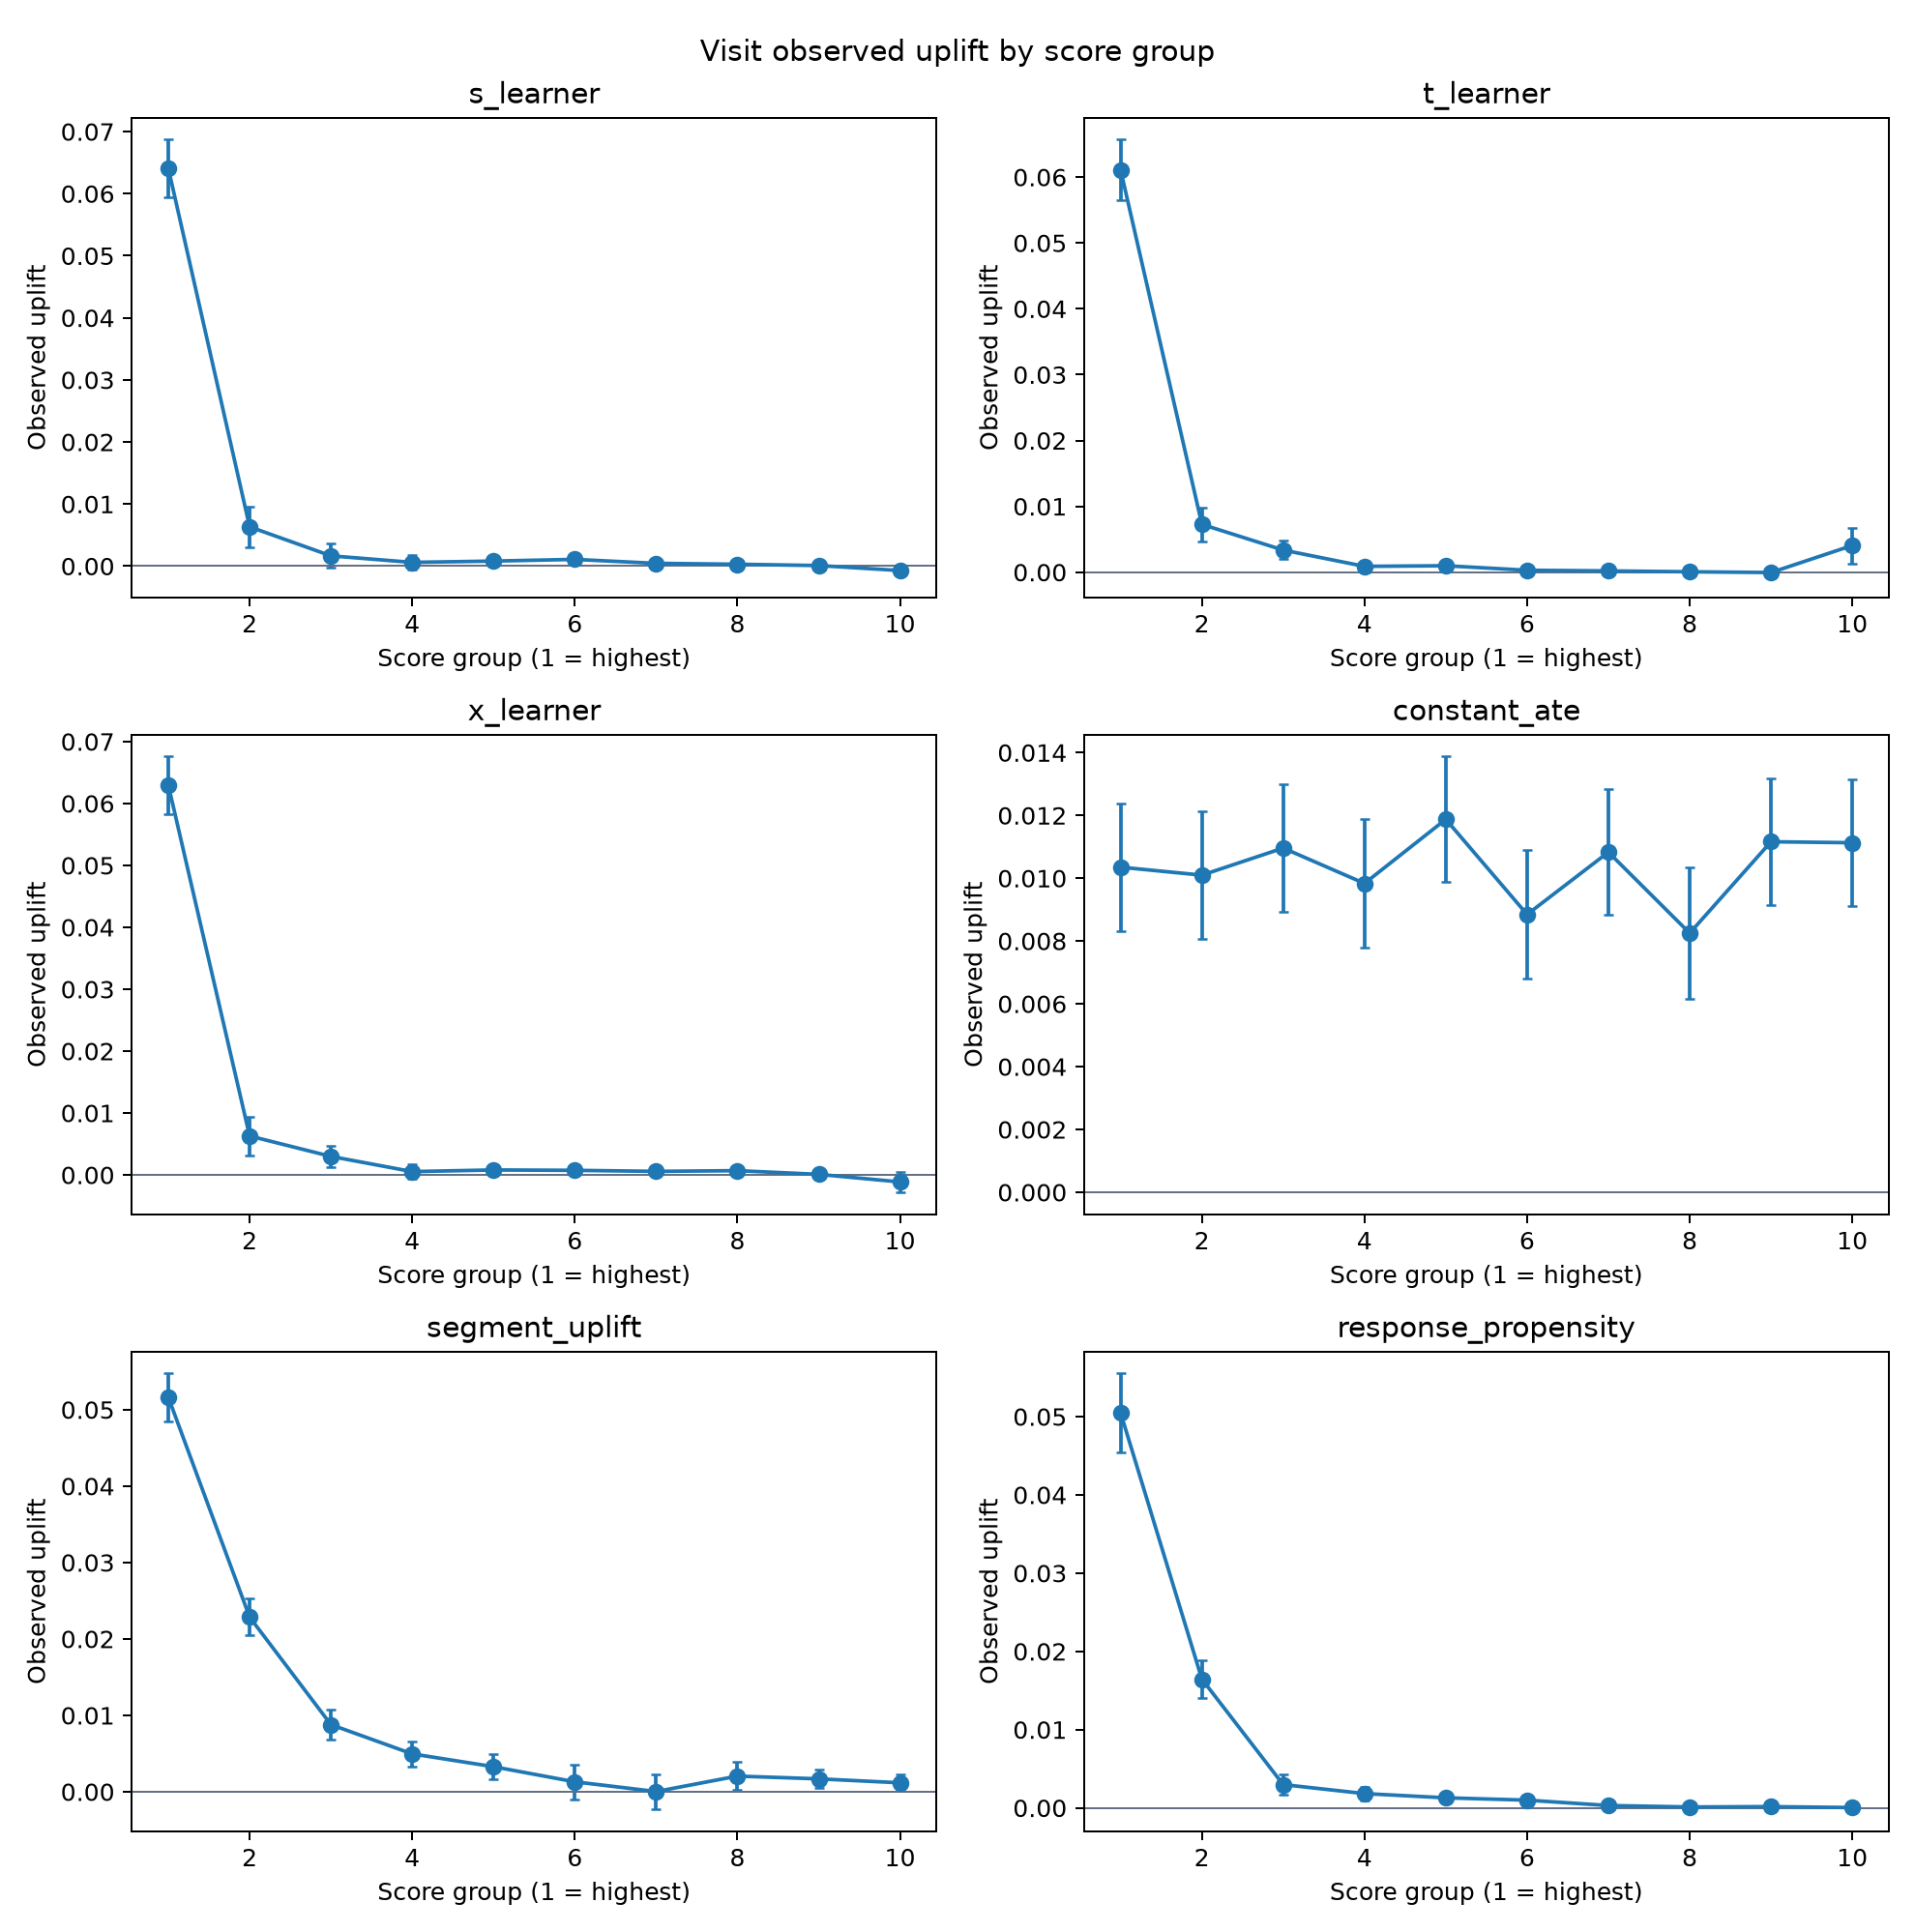

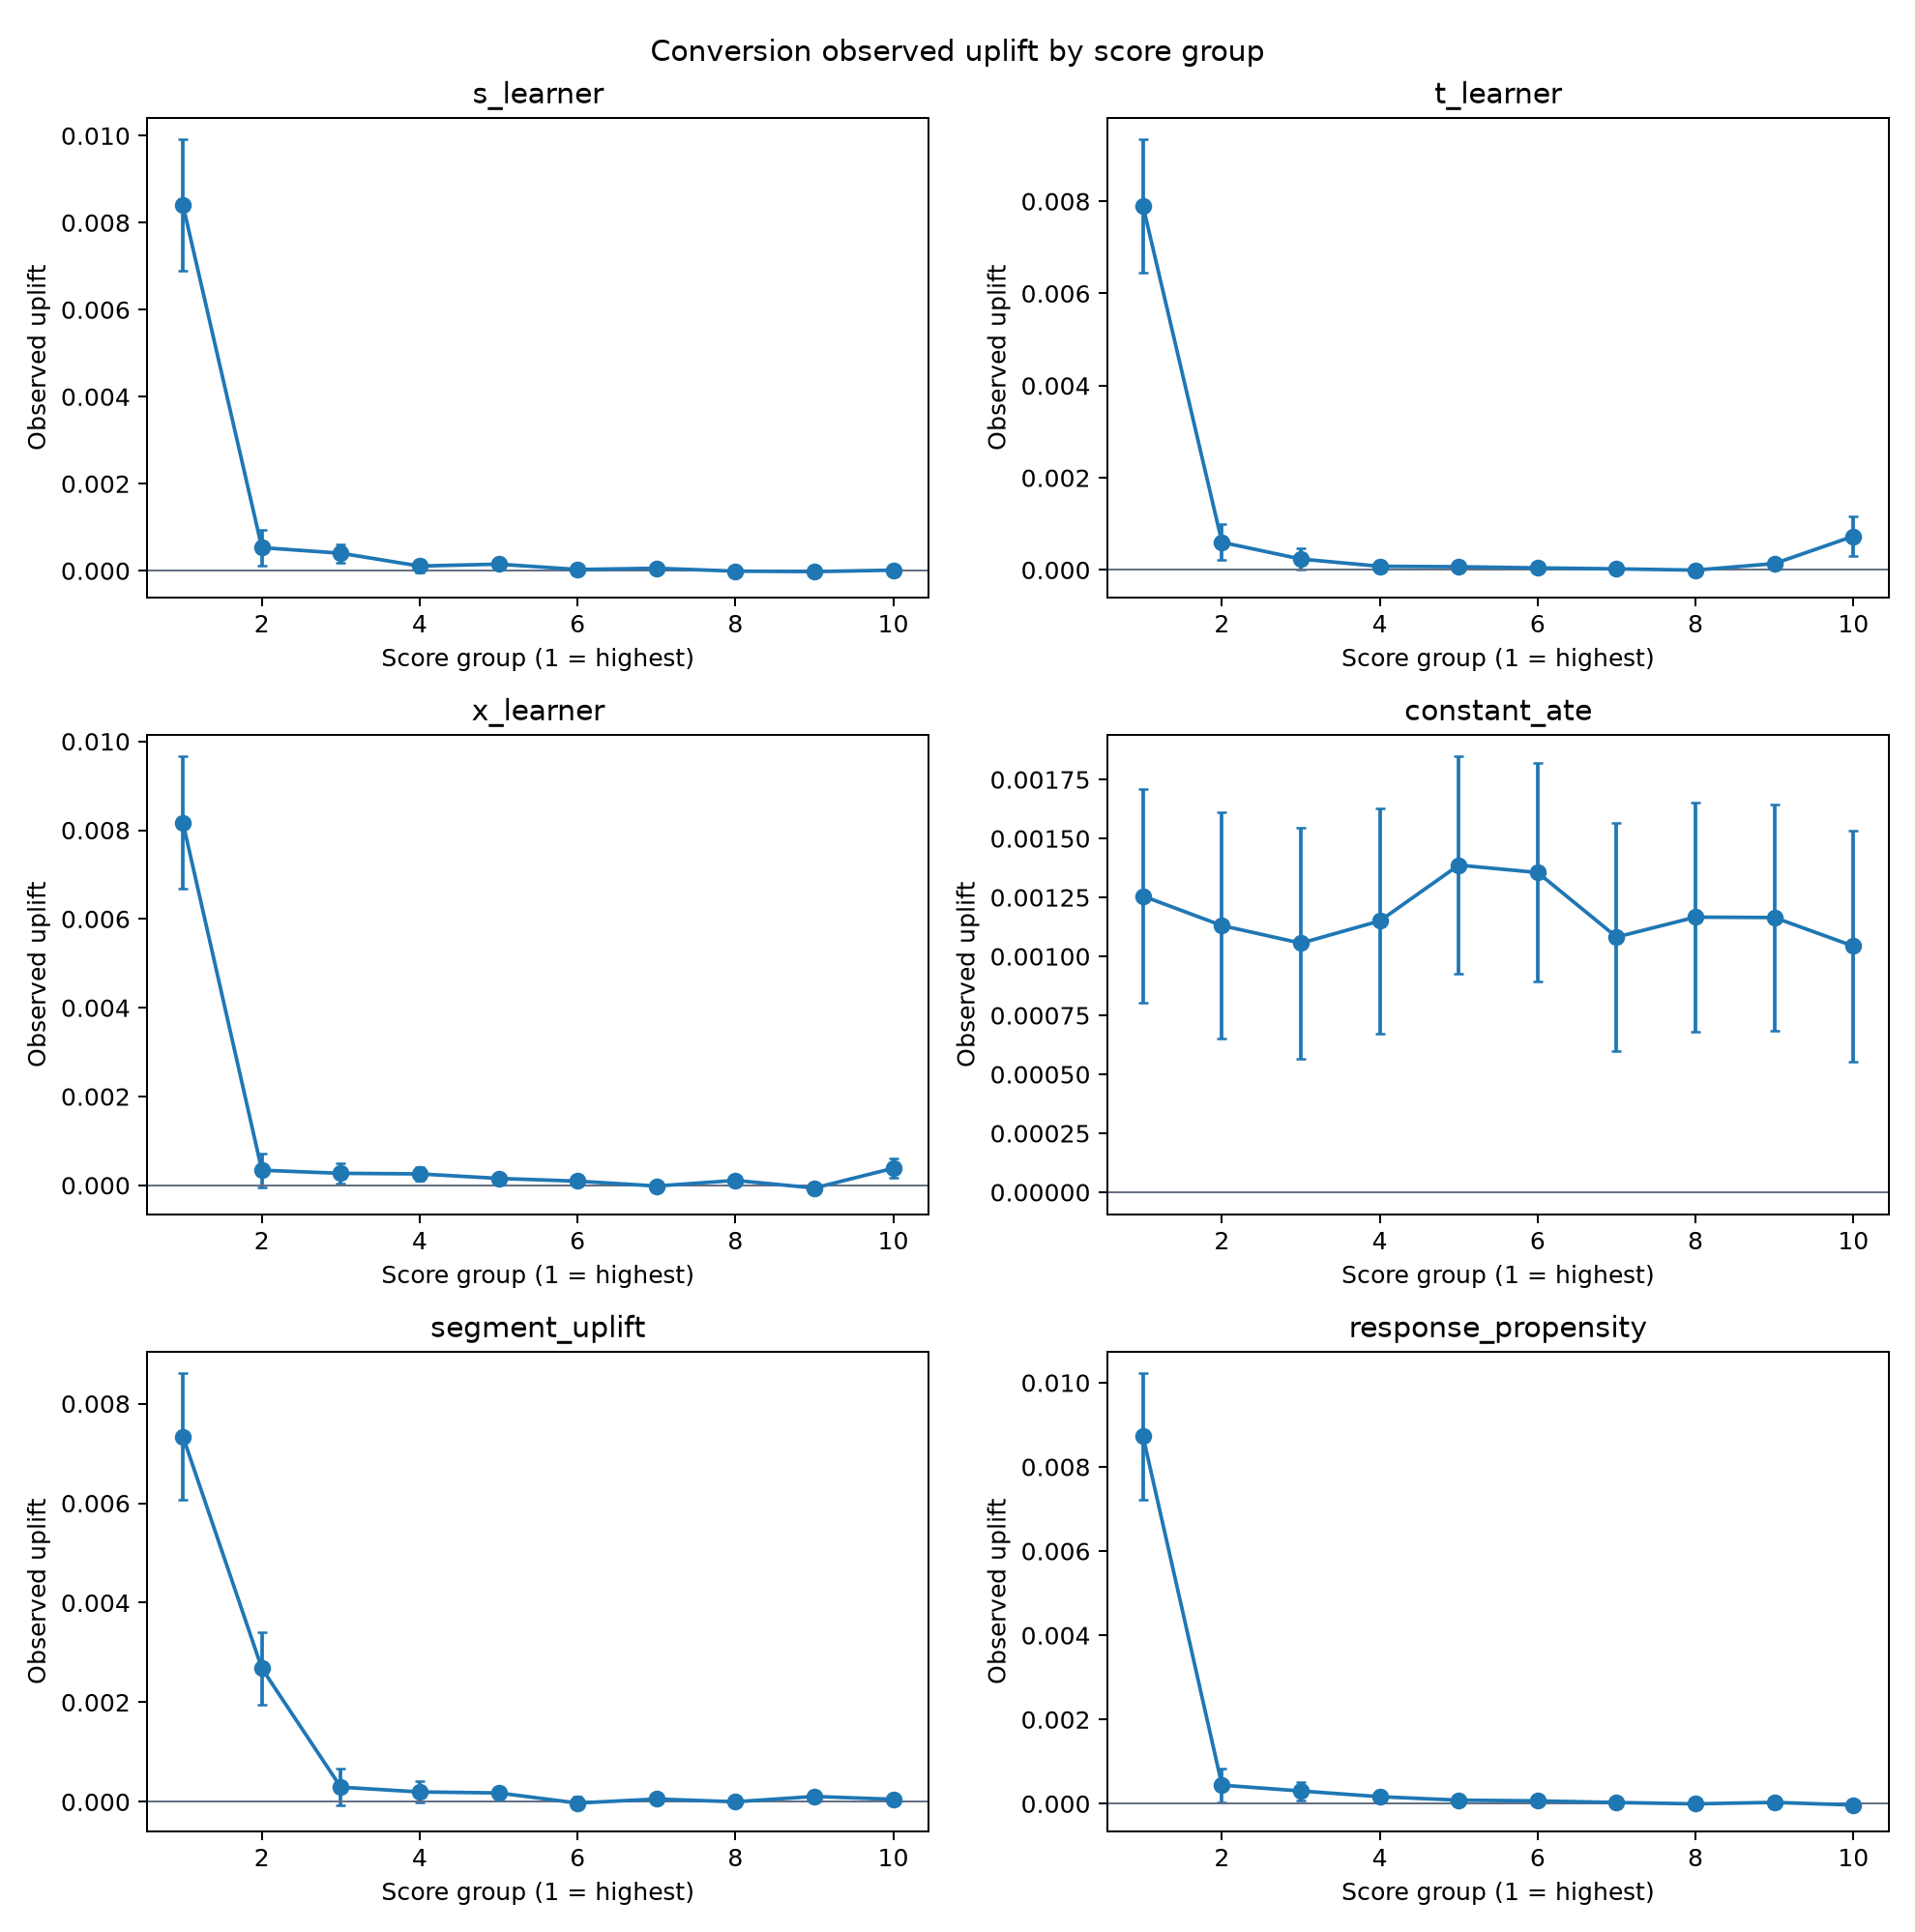

In [5]:
group_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_group_effects.csv"
    if path.exists():
        group_tables.append(pd.read_csv(path))
if group_tables:
    group_effects = pd.concat(group_tables, ignore_index=True)
    display(group_effects.head(24).round(6))
    for outcome in config["outcomes"]:
        figure_path = FIGURE_DIRECTORY / f"{outcome}_group_uplift.png"
        if figure_path.exists():
            display(Image(filename=str(figure_path)))
else:
    display(Markdown("Group-level uplift results are not available yet."))

## 7. Cumulative gain, AUUC, and Qini

At targeting fraction $q$, cumulative gain is $G(q)=n(q)(\bar{Y}_1(q)-\bar{Y}_0(q))$.
This project calculates AUUC with trapezoidal integration over the saved 5% grid, including the
origin: $\mathrm{AUUC}=\int_0^1 G(q)dq$. The random reference is $qG(1)$, so
$\mathrm{Qini}=\mathrm{AUUC}-\tfrac{1}{2}G(1)$. Values are unnormalized counts of incremental
outcomes, not library-normalized scores.

,outcome_name,model_name,auuc,qini,endpoint_gain
10,conversion,response_propensity,2981.5439,1333.3219,3296.4439
7,conversion,s_learner,2971.5566,1323.3347,3296.4439
12,conversion,segment_uplift,2892.9513,1244.7293,3296.4439
9,conversion,x_learner,2858.9287,1210.7067,3296.4439
8,conversion,t_learner,2777.5700,1129.3480,3296.4439
11,conversion,constant_ate,1674.8197,26.5977,3296.4439
13,conversion,random_uniform,1648.2219,0.0000,3296.4439
2,visit,x_learner,25098.5858,10651.9271,28893.3175
0,visit,s_learner,24997.0768,10550.4181,28893.3175
1,visit,t_learner,24559.3495,10112.6907,28893.3175


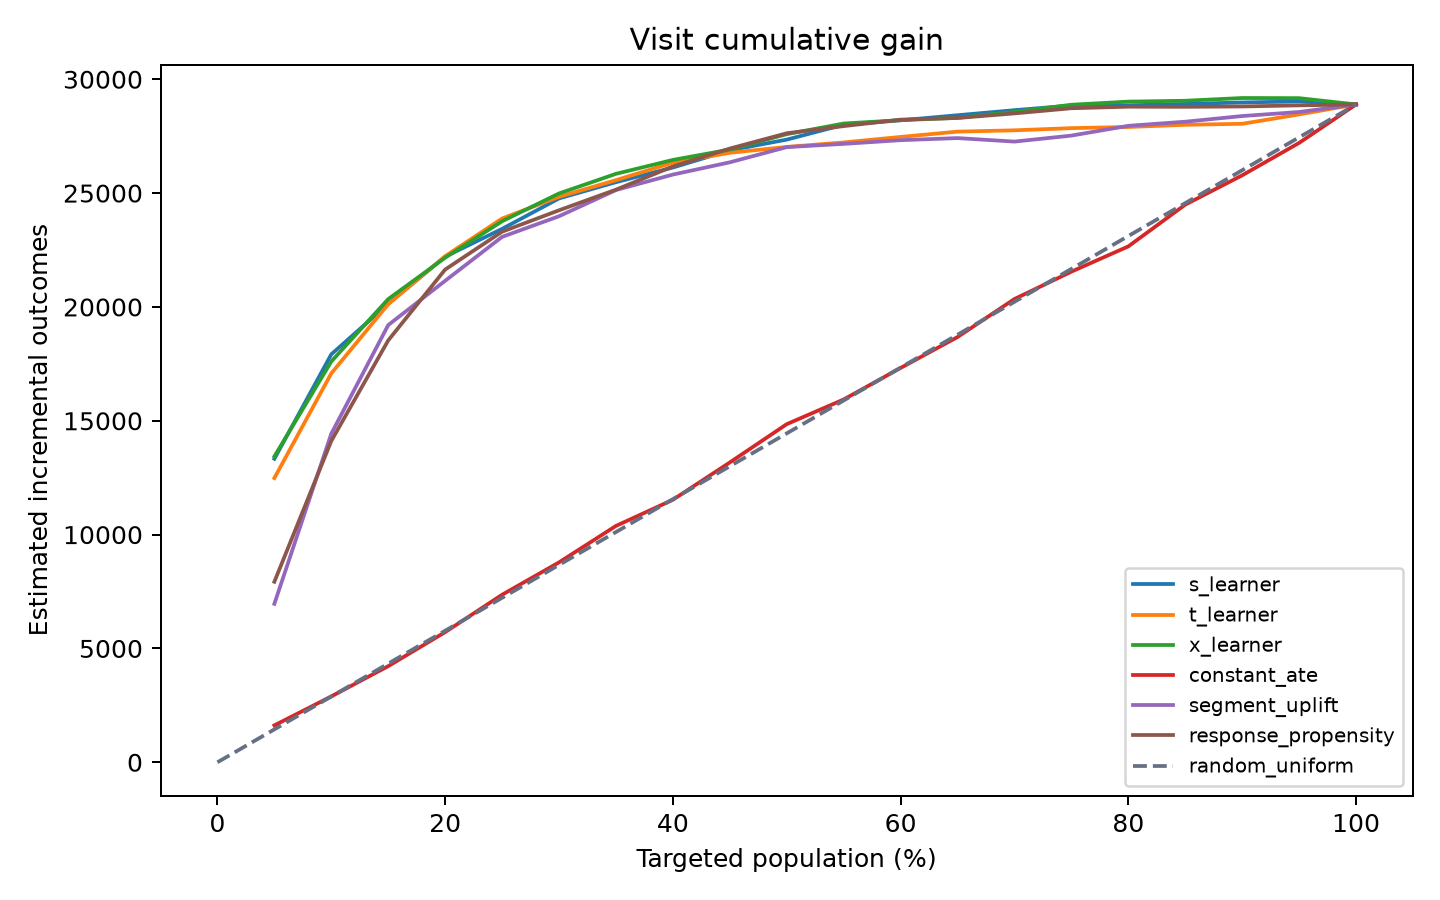

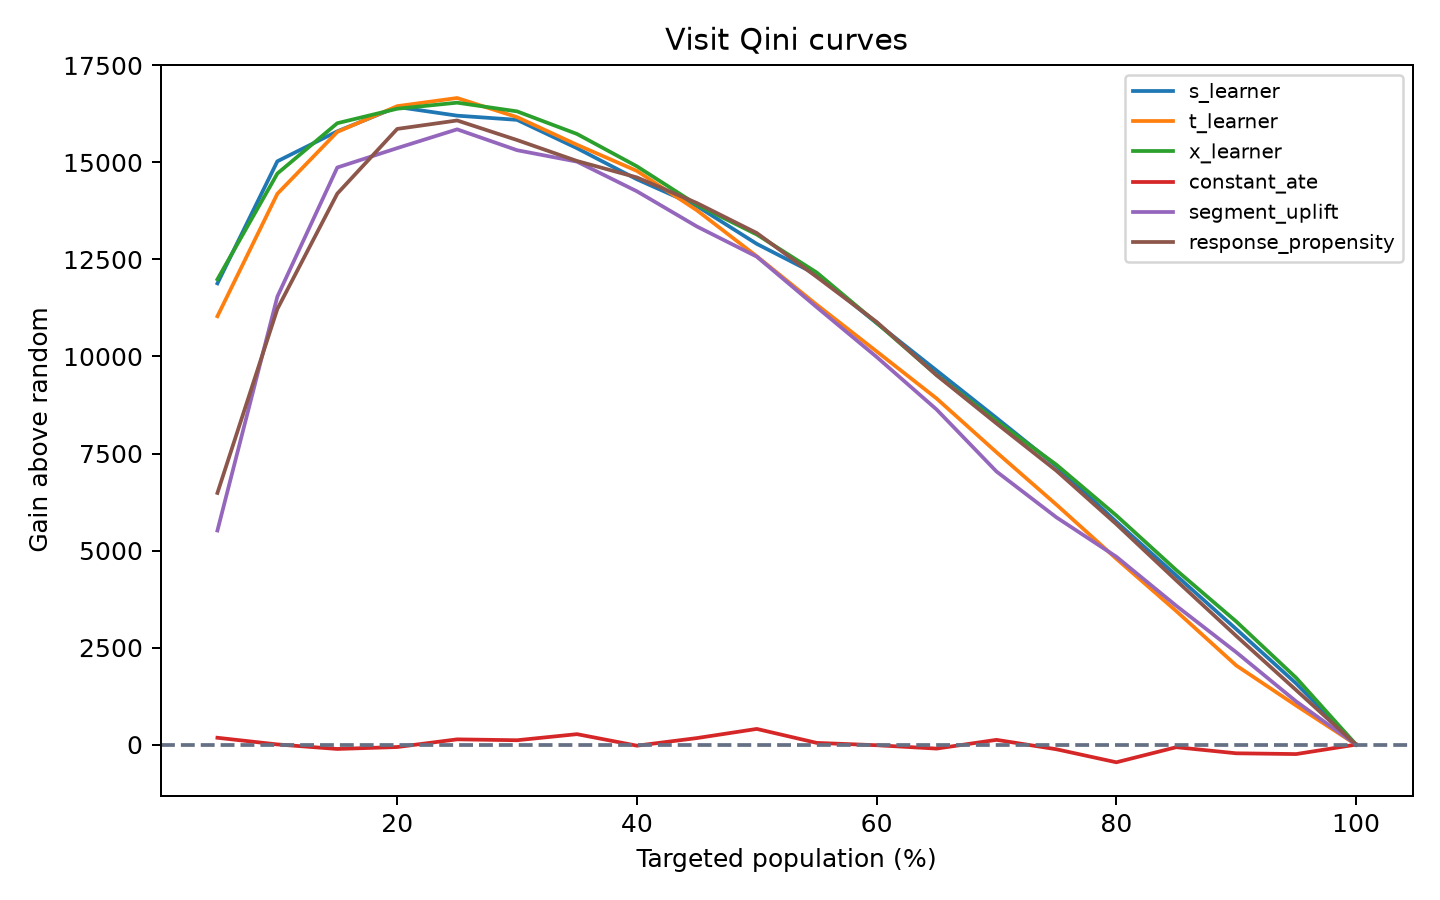

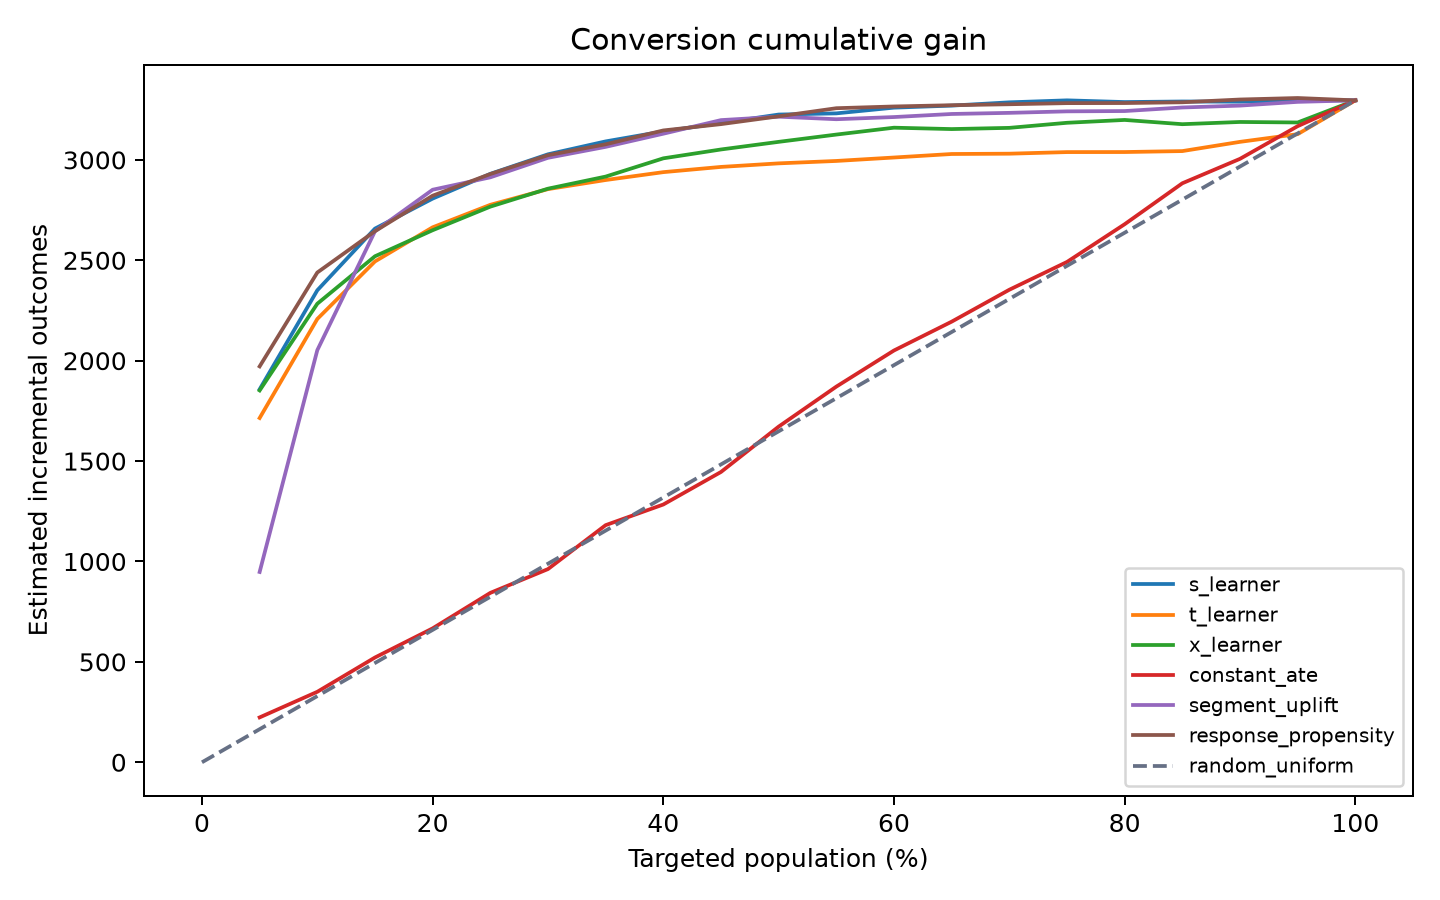

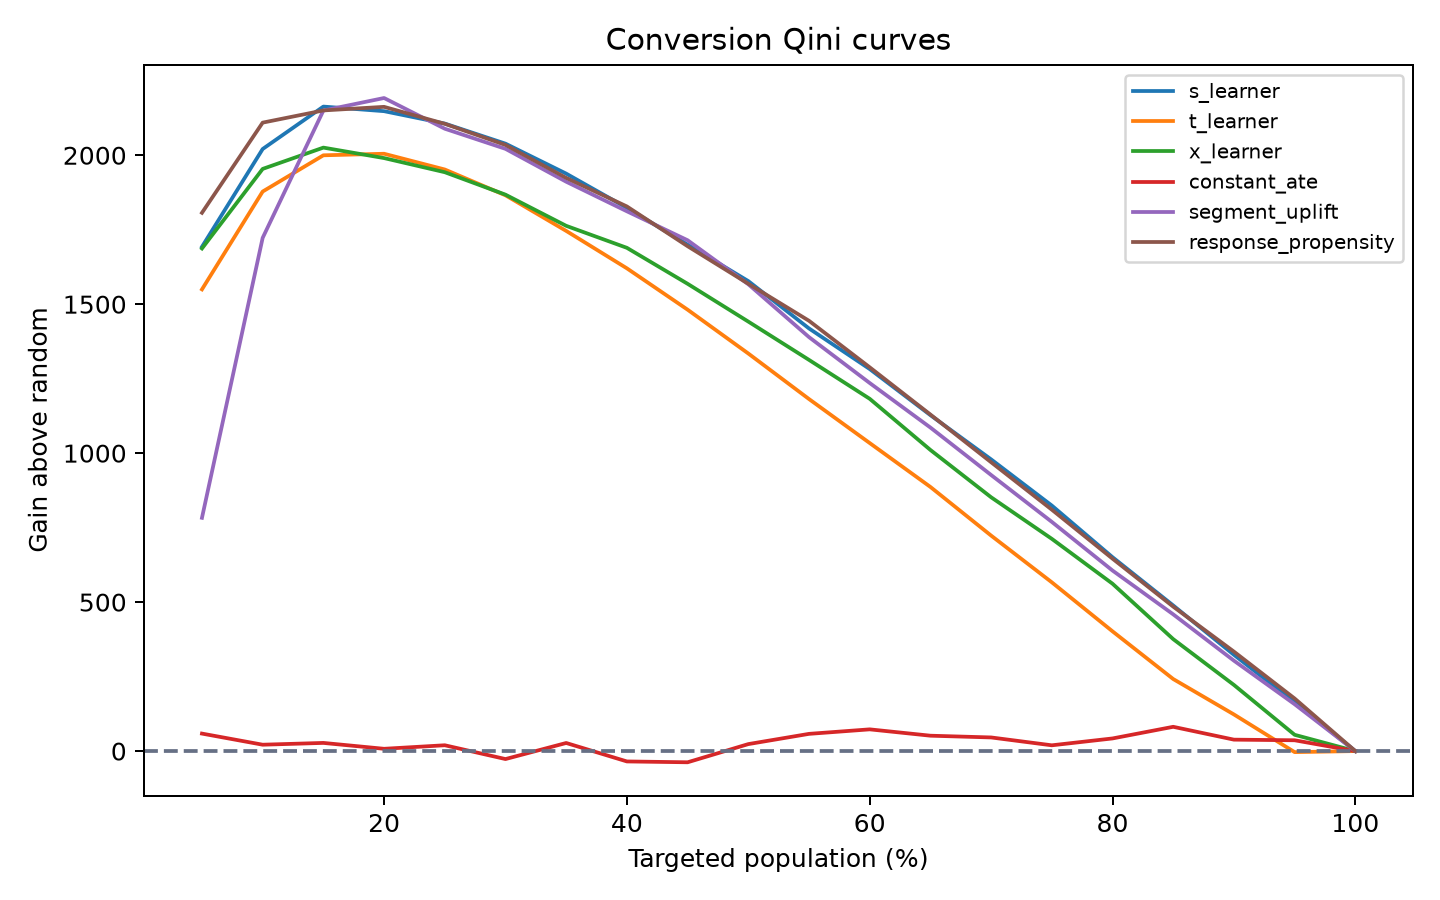

In [6]:
metric_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_model_metrics.csv"
    if path.exists():
        metric_tables.append(pd.read_csv(path))
if metric_tables:
    metrics = pd.concat(metric_tables, ignore_index=True)
    display(metrics.sort_values(["outcome_name", "qini"], ascending=[True, False]).round(4))
    for outcome in config["outcomes"]:
        for suffix in ("cumulative_gain", "qini_curve"):
            figure_path = FIGURE_DIRECTORY / f"{outcome}_{suffix}.png"
            if figure_path.exists():
                display(Image(filename=str(figure_path)))
else:
    display(Markdown("Cumulative-gain metrics are not available yet."))

## 8. Uplift score calibration

,outcome_name,model_name,intercept,slope,ranking_changed
0,visit,s_learner,-0.000474,1.094343,False
1,visit,t_learner,0.001123,0.908442,False
2,visit,x_learner,-0.000334,1.058056,False
3,conversion,s_learner,0.000043,0.998448,False
4,conversion,t_learner,0.000164,0.828073,False
5,conversion,x_learner,0.000062,0.920304,False


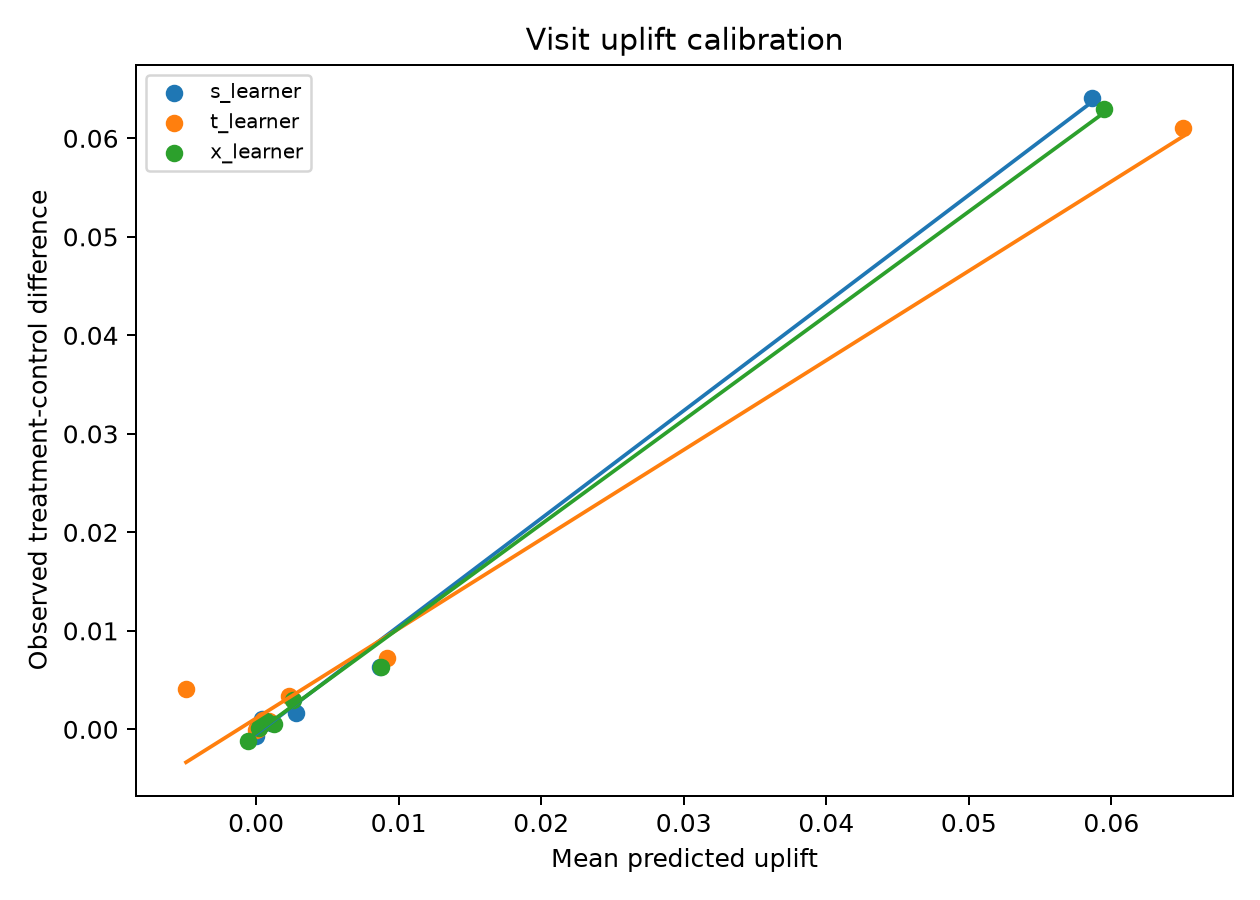

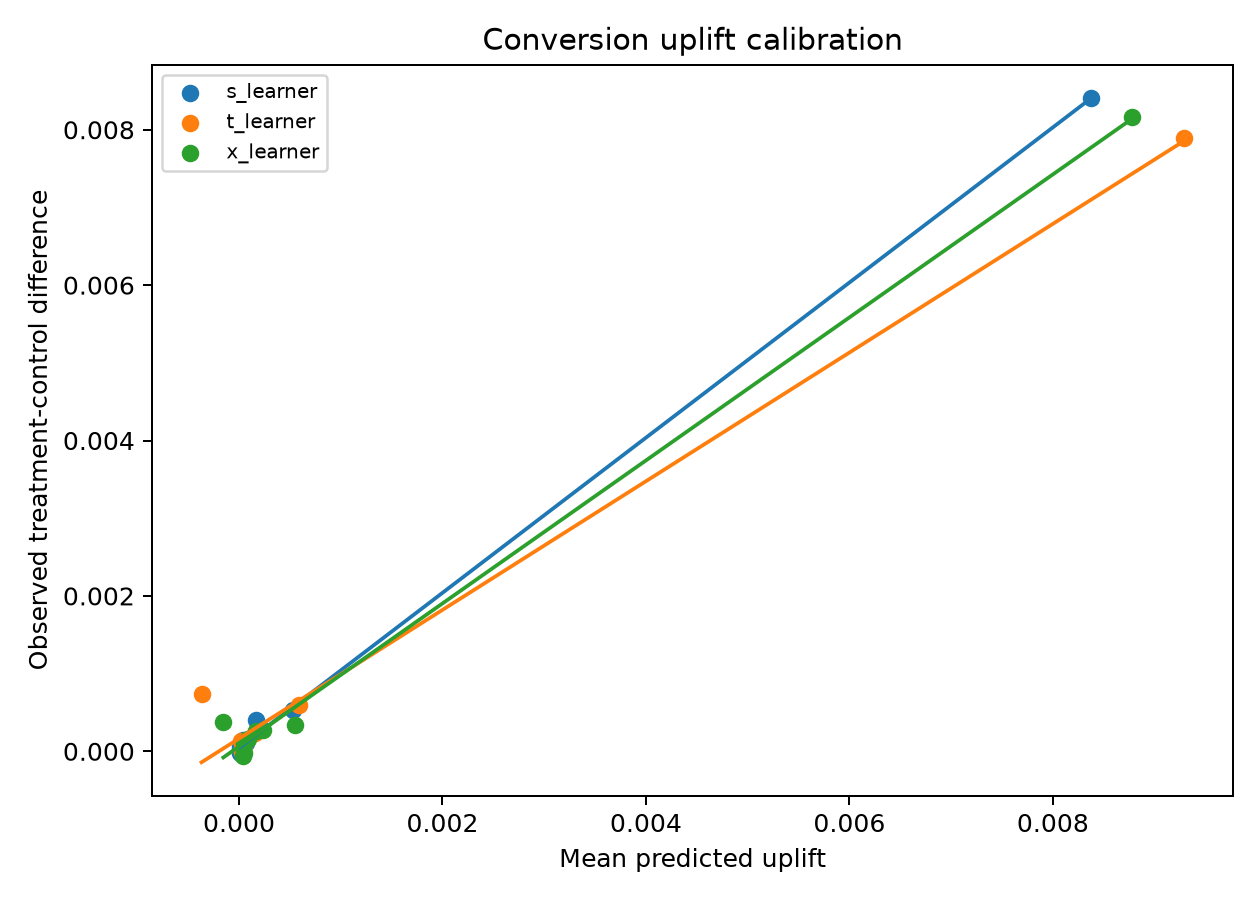

In [7]:
parameter_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_calibration_parameters.csv"
    if path.exists():
        parameter_tables.append(pd.read_csv(path))
if parameter_tables:
    calibration_parameters = pd.concat(parameter_tables, ignore_index=True)
    display(calibration_parameters.round(6))
    assert (~calibration_parameters["ranking_changed"]).all()
    for outcome in config["outcomes"]:
        figure_path = FIGURE_DIRECTORY / f"{outcome}_uplift_calibration.png"
        if figure_path.exists():
            display(Image(filename=str(figure_path)))
else:
    display(Markdown("Calibration results are not available yet."))

## 9. Paired-bootstrap uncertainty

In [8]:
uncertainty_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_uncertainty.csv"
    if path.exists():
        uncertainty_tables.append(pd.read_csv(path))
if uncertainty_tables:
    uncertainty = pd.concat(uncertainty_tables, ignore_index=True)
    key_metrics = uncertainty[
        uncertainty["metric"].isin(
            ["qini", "qini_minus_response", "gain_at_10pct", "gain_at_20pct", "gain_at_30pct"]
        )
    ]
    display(key_metrics.round(4))
else:
    display(Markdown("Uncertainty intervals are not available yet."))

,outcome_name,model_name,metric,estimate,ci_lower,ci_upper,bootstrap_replicates
2,visit,constant_ate,gain_at_10pct,2893.8383,2295.4041,3475.1164,200
4,visit,constant_ate,gain_at_20pct,5716.2624,4986.0825,6517.9977,200
6,visit,constant_ate,gain_at_30pct,8780.5416,7962.9251,9749.3292,200
8,visit,constant_ate,qini,0.3584,-501.2680,586.3712,200
9,visit,constant_ate,qini_minus_response,-9905.5209,-10963.9343,-9008.6326,200
11,visit,response_propensity,gain_at_10pct,14113.7063,12584.5279,15750.6707,200
12,visit,response_propensity,gain_at_20pct,21642.3701,20059.9995,23338.9594,200
13,visit,response_propensity,gain_at_30pct,24244.6673,22591.5851,26158.4036,200
14,visit,response_propensity,qini,9905.8792,9204.0005,10801.1343,200
17,visit,s_learner,gain_at_10pct,17918.9356,16656.5397,19419.8809,200


## 10. Top 10%, 20%, and 30% strategy comparison

,outcome_name,model_name,target_fraction,selected_rows,cumulative_uplift,cumulative_gain,gain_above_random
0,visit,s_learner,0.1,279575.0,0.06409,17918.93562,15029.60386
1,visit,s_learner,0.2,559150.0,0.03972,22208.07588,16429.41237
2,visit,s_learner,0.3,838725.0,0.02953,24765.23663,16097.24137
3,visit,t_learner,0.1,279575.0,0.06110,17081.64880,14192.31705
4,visit,t_learner,0.2,559150.0,0.03975,22228.89069,16450.22718
5,visit,t_learner,0.3,838725.0,0.02961,24835.12150,16167.12624
6,visit,x_learner,0.1,279575.0,0.06297,17603.53911,14714.20736
7,visit,x_learner,0.2,559150.0,0.03964,22162.55714,16383.89364
8,visit,x_learner,0.3,838725.0,0.02979,24983.73691,16315.74166
9,visit,response_propensity,0.1,279575.0,0.05048,14113.70629,11224.37453


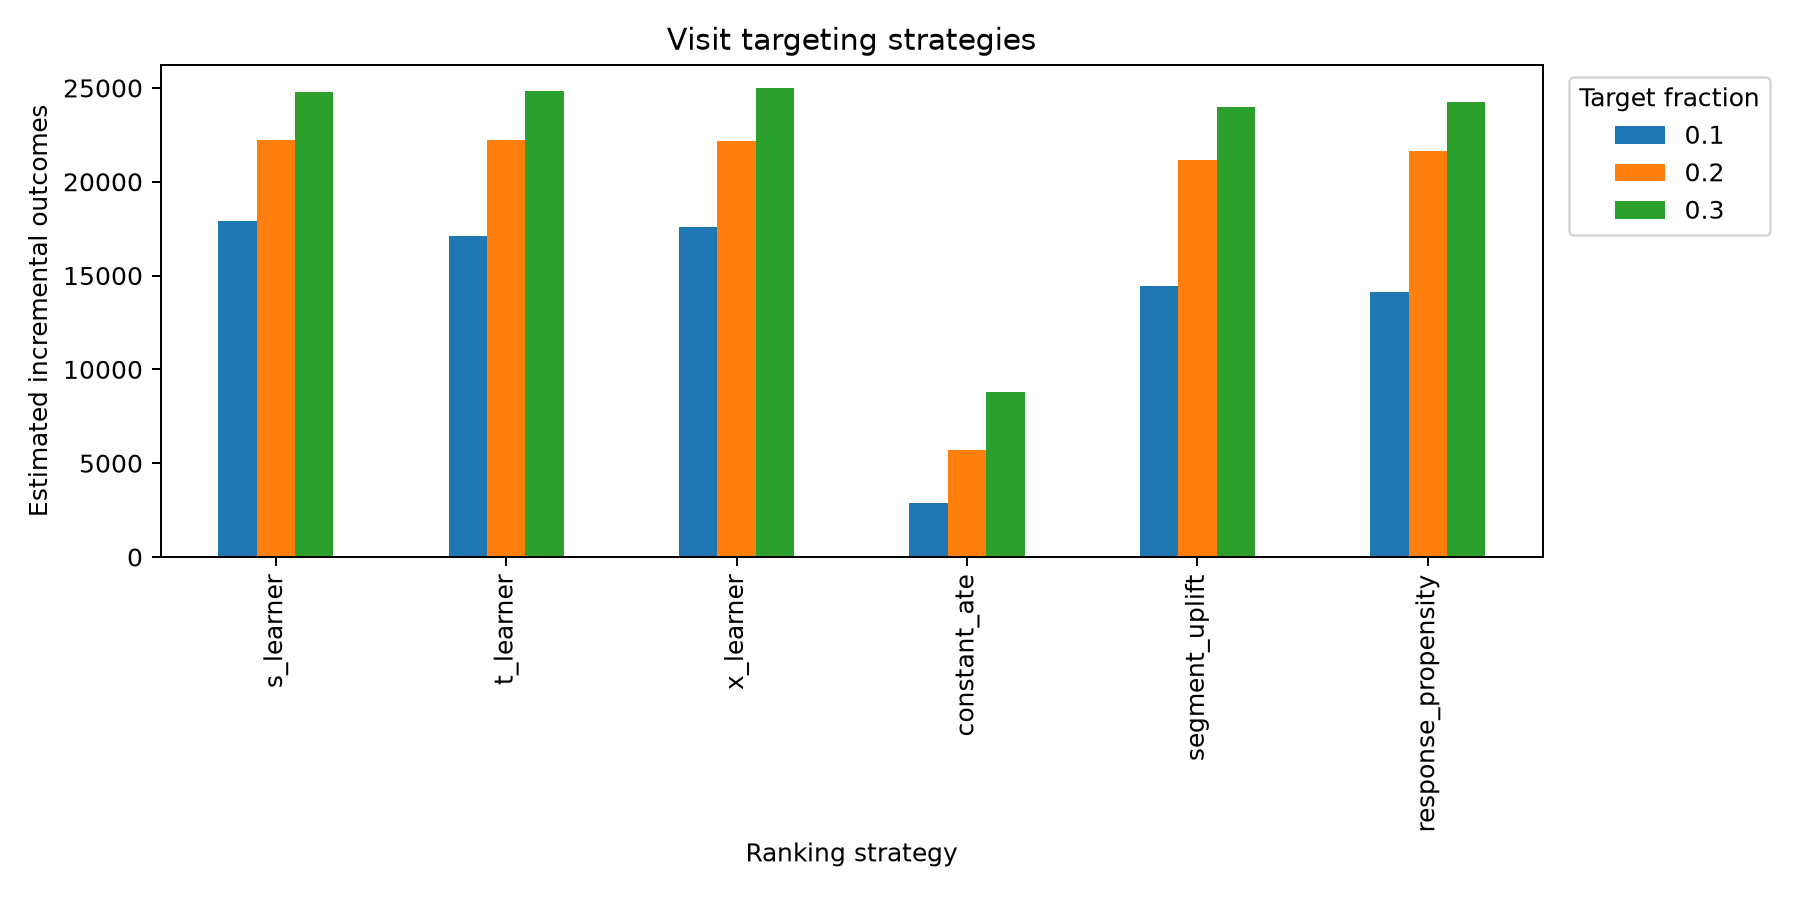

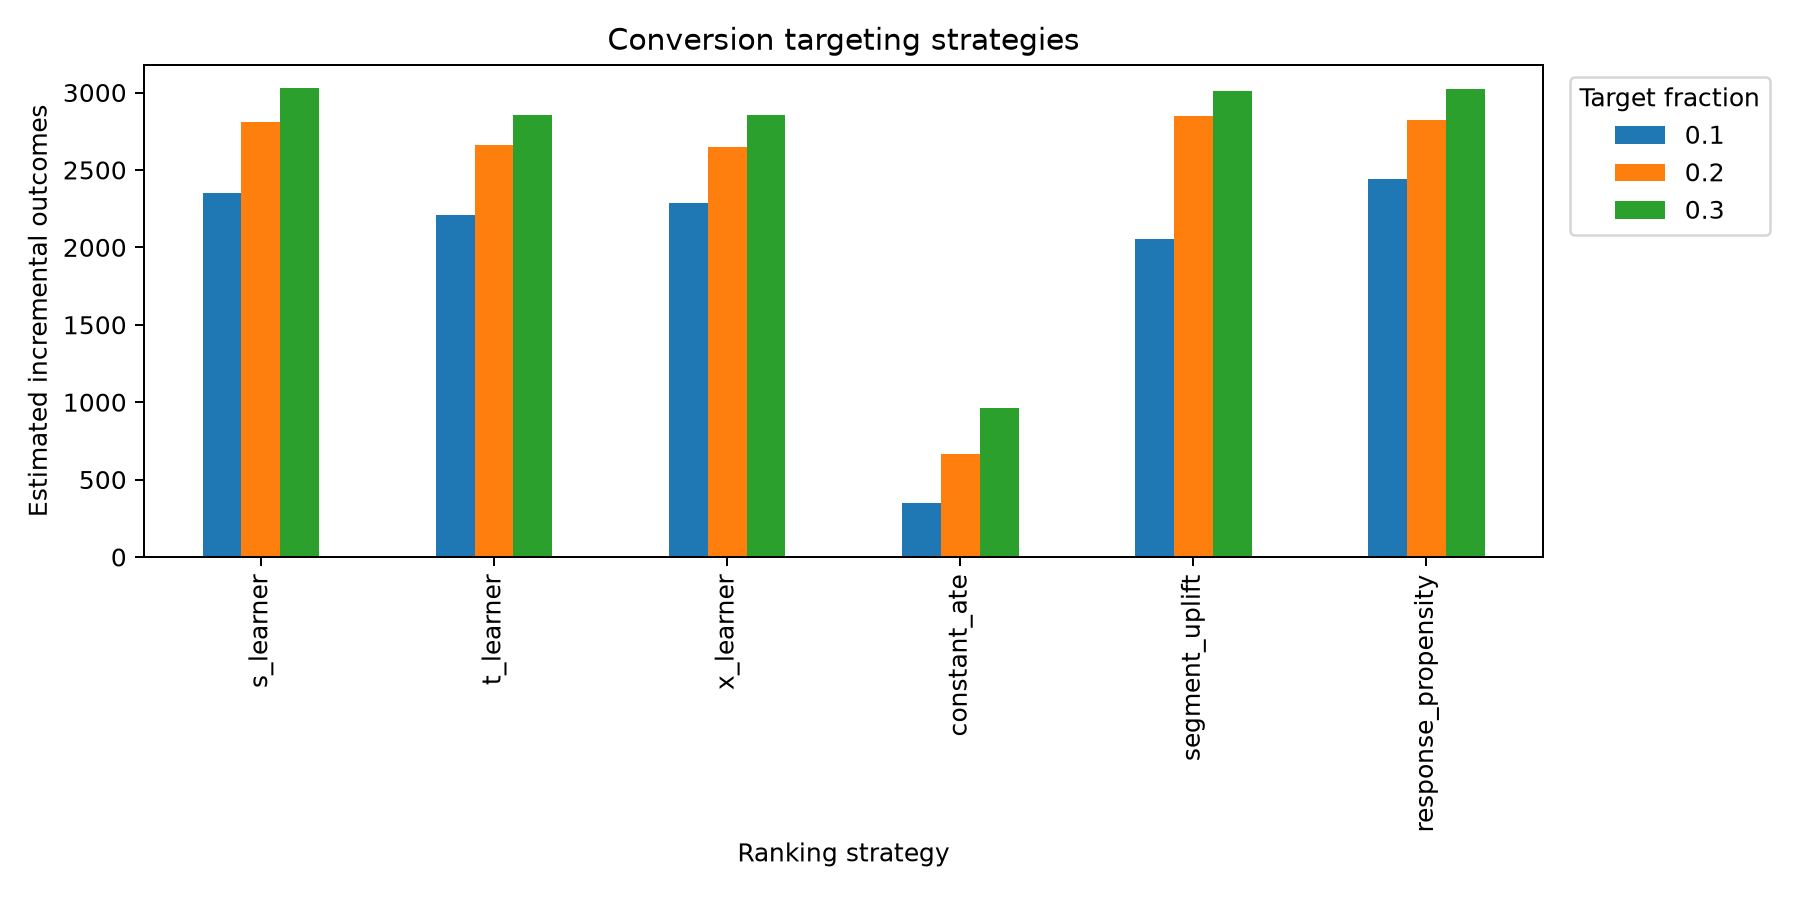

In [9]:
policy_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_policy_summary.csv"
    if path.exists():
        table = pd.read_csv(path)
        policy_tables.append(table[table["target_fraction"].isin(config["main_decision_rates"])])
if policy_tables:
    policy = pd.concat(policy_tables, ignore_index=True)
    display(
        policy[
            [
                "outcome_name", "model_name", "target_fraction", "selected_rows",
                "cumulative_uplift", "cumulative_gain", "gain_above_random"
            ]
        ].round(5)
    )
    for outcome in config["outcomes"]:
        figure_path = FIGURE_DIRECTORY / f"{outcome}_targeting_comparison.png"
        if figure_path.exists():
            display(Image(filename=str(figure_path)))
else:
    display(Markdown("Targeting-strategy results are not available yet."))

## 11. Phase 3 stability across model runs

In [10]:
stability_tables = []
for outcome in config["outcomes"]:
    path = TABLE_DIRECTORY / f"{outcome}_phase3_stability.csv"
    if path.exists():
        stability_tables.append(pd.read_csv(path))
if stability_tables:
    stability = pd.concat(stability_tables, ignore_index=True)
    display(stability.round(5))
else:
    display(Markdown("Current-implementation stability results are not available yet."))

,outcome_name,model_name,reference_seed,comparison_seed,spearman_rank_correlation,top_fraction,top_set_overlap,reference_mean_uplift,comparison_mean_uplift,comparison_runtime_seconds
0,visit,s_learner,20260816,20260817,0.97841,0.1,0.94001,0.00727,0.00725,485.99051
1,visit,t_learner,20260816,20260817,0.85392,0.1,0.88488,0.00738,0.00737,485.99051
2,visit,x_learner,20260816,20260817,0.97779,0.1,0.96491,0.00738,0.00739,485.99051
3,conversion,s_learner,20260816,20260817,0.95103,0.1,0.95454,0.00093,0.00096,682.27002
4,conversion,t_learner,20260816,20260817,0.87581,0.1,0.89550,0.00099,0.00099,682.27002
5,conversion,x_learner,20260816,20260817,0.95295,0.1,0.93832,0.00099,0.00099,682.27002


## 12. Final model and targeting recommendations

In [11]:
recommendation_path = TABLE_DIRECTORY / "final_model_recommendations.csv"
comparison_path = TABLE_DIRECTORY / "final_model_comparison.csv"
if recommendation_path.exists() and comparison_path.exists():
    model_comparison = pd.read_csv(comparison_path)
    recommendations = pd.read_csv(recommendation_path)
    display(model_comparison.round(4))
    display(recommendations.round(4))
else:
    display(Markdown("Final recommendations will appear after both outcomes are evaluated."))

,outcome_name,model_name,complexity_rank,auuc,qini,qini_minus_response,qini_minus_response_ci_lower,qini_minus_response_ci_upper,mean_spearman_rank_correlation,minimum_spearman_rank_correlation,mean_top_set_overlap,minimum_top_set_overlap,analysis_status
0,visit,s_learner,1,24997.0768,10550.4181,644.5388,412.9949,855.5379,0.9784,0.9784,0.9400,0.9400,exploratory_completion_requested_after_initial...
1,visit,t_learner,2,24559.3495,10112.6907,206.8115,-433.7677,878.0946,0.8539,0.8539,0.8849,0.8849,exploratory_completion_requested_after_initial...
2,visit,x_learner,3,25098.5858,10651.9271,746.0478,373.5824,1075.3559,0.9778,0.9778,0.9649,0.9649,exploratory_completion_requested_after_initial...
3,conversion,s_learner,1,2971.5566,1323.3347,-9.9872,-18.1334,-1.0971,0.9510,0.9510,0.9545,0.9545,exploratory_completion_requested_after_initial...
4,conversion,t_learner,2,2777.5700,1129.3480,-203.9739,-313.6722,-70.5426,0.8758,0.8758,0.8955,0.8955,exploratory_completion_requested_after_initial...
5,conversion,x_learner,3,2858.9287,1210.7067,-122.6152,-167.9049,-62.0555,0.9530,0.9530,0.9383,0.9383,exploratory_completion_requested_after_initial...


,outcome_name,point_qini_leader,recommended_uplift_model,simplicity_rule_applied,deployment_ranking,uplift_model_beats_response_at_95pct,recommended_target_fraction,selected_users,selected_group_uplift,estimated_incremental_outcomes,incremental_outcomes_ci_lower,incremental_outcomes_ci_upper,uplift_model_qini,qini_minus_response_ci_lower,qini_minus_response_ci_upper,mean_stability_rank_correlation,mean_stability_top_set_overlap,selection_rule,analysis_status
0,visit,x_learner,s_learner,True,s_learner,True,0.3,838725,0.0295,24765.2366,23315.2072,26510.1664,10550.4181,412.9949,855.5379,0.9784,0.9400,start from highest uplift-model Qini; choose t...,exploratory_completion_requested_after_initial...
1,conversion,s_learner,s_learner,False,response_propensity,False,0.3,838725,0.0036,3023.4212,2579.0535,3506.9838,1323.3347,-18.1334,-1.0971,0.9510,0.9545,start from highest uplift-model Qini; choose t...,exploratory_completion_requested_after_initial...


The selection rule is fixed in code: start with the uplift learner having the highest Qini, then
choose the simplest learner that is not significantly worse under the paired Qini comparison.
Deploy that uplift ranking only if its paired Qini difference versus response targeting has a 95%
confidence interval above zero. Otherwise retain response targeting for deployment. Among Top
10%, 20%, and 30%, choose the rate with the largest bootstrap lower confidence bound for
incremental outcomes.

## 13. Visit-versus-conversion targeting

,visit_model,conversion_model,target_fraction,score_spearman_rank_correlation,shared_selected_users,shared_as_pct_of_each_targeted_set,shared_as_pct_of_test_population,analysis_status,conversion_gain_using_visit_policy,conversion_gain_using_visit_policy_ci_lower,...,conversion_gain_using_conversion_policy_ci_upper,conversion_gain_using_conversion_policy_uplift,visit_gain_using_conversion_policy,visit_gain_using_conversion_policy_ci_lower,visit_gain_using_conversion_policy_ci_upper,visit_gain_using_conversion_policy_uplift,visit_gain_using_visit_policy,visit_gain_using_visit_policy_ci_lower,visit_gain_using_visit_policy_ci_upper,visit_gain_using_visit_policy_uplift
0,s_learner,s_learner,0.1,0.8883,217879,77.9322,7.7932,exploratory_completion_requested_after_initial...,2140.7482,1759.2713,...,2770.5573,0.0084,16867.6710,15531.8143,18203.5278,0.0603,17918.9356,16626.0594,19211.8119,0.0641
1,s_learner,s_learner,0.2,0.8883,473997,84.7710,16.9542,exploratory_completion_requested_after_initial...,2899.2623,2494.2220,...,3228.8408,0.0050,21891.7715,20283.7881,23499.7550,0.0392,22208.0759,20622.6407,23793.5110,0.0397
2,s_learner,s_learner,0.3,0.8883,710008,84.6533,25.3960,exploratory_completion_requested_after_initial...,3011.1033,2596.3381,...,3449.1716,0.0036,24494.1187,22786.4818,26201.7556,0.0292,24765.2366,23076.3930,26454.0803,0.0295


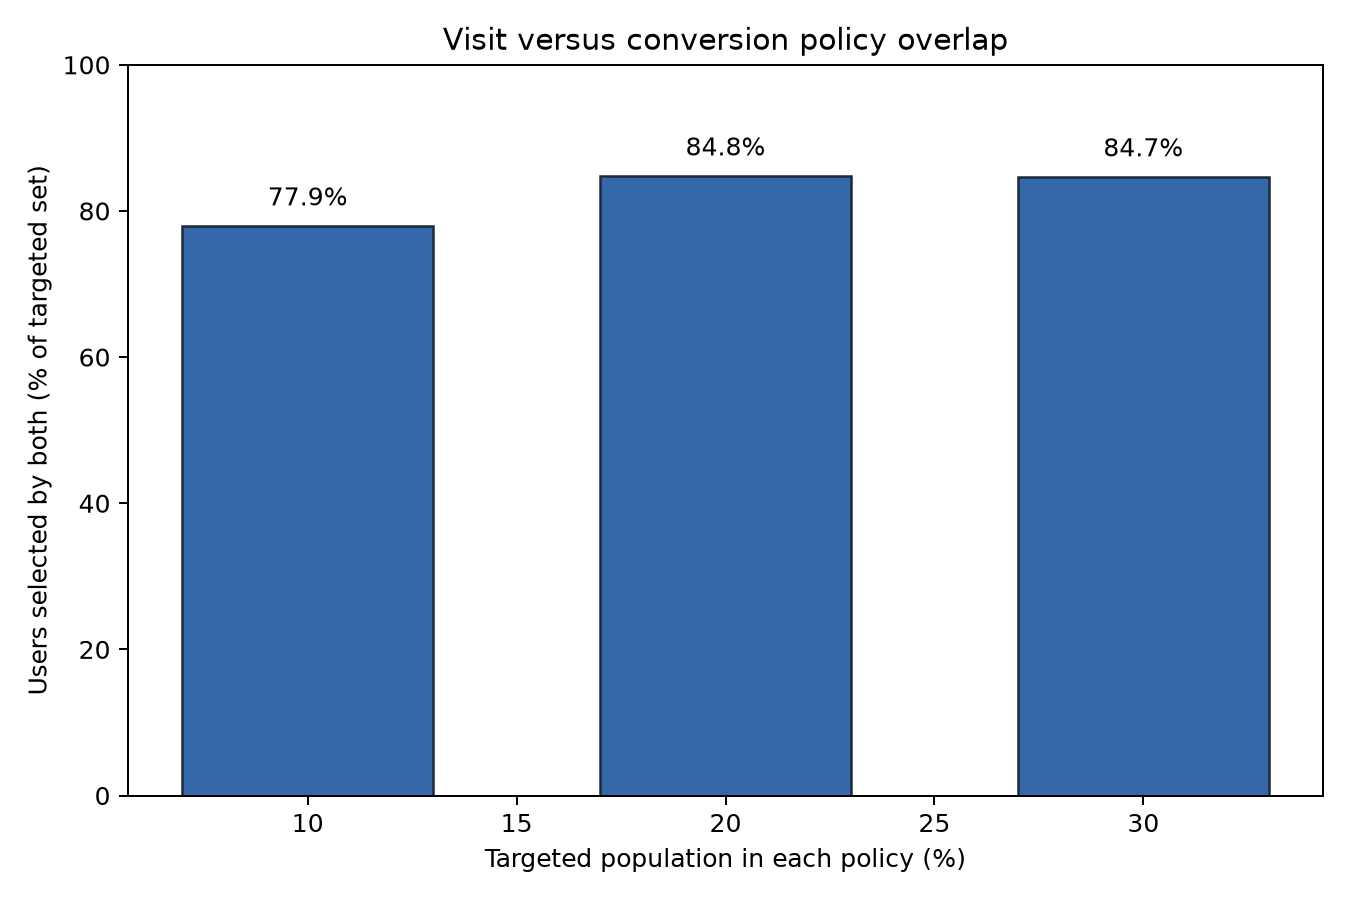

In [12]:
cross_path = TABLE_DIRECTORY / "visit_conversion_policy_comparison.csv"
overlap_figure = FIGURE_DIRECTORY / "visit_conversion_policy_overlap.png"
if cross_path.exists():
    cross_policy = pd.read_csv(cross_path)
    display(cross_policy.round(4))
if overlap_figure.exists():
    display(Image(filename=str(overlap_figure)))

## 14. Reproducible commands

```bash
# Freeze rules and prepare response baselines without test outcomes
.venv/bin/python src/phase4_uplift_evaluation.py prepare --outcome both

# Open test outcomes and run the frozen evaluation
.venv/bin/python src/phase4_uplift_evaluation.py evaluate --outcome both

# Rebuild and execute this reader-facing notebook
.venv/bin/python src/build_phase4_notebook.py
.venv/bin/jupyter nbconvert --execute --to notebook --inplace \
  notebook/06_uplift_model_evaluation.ipynb
```